# Análisis Filogenético PGLS: Predictibilidad del Modelo de Clasificación de Aves

Este notebook evalúa si la predictibilidad del modelo de clasificación de aves (F1-score) se explica por filogenia, y qué variables de AVONET explican mejor el rendimiento después de controlar por efectos filogenéticos.

## Contenido
1. Configuración y Carga de Datos
2. Reconciliación de Nombres de Especies
3. Preparación de Datos
4. Señal Filogenética (Lambda de Pagel, K de Blomberg)
5. Análisis PGLS
6. Importancia de Variables
7. Visualizaciones
8. Conclusiones

## 1. Configuración y Carga de Datos

In [1]:
# Librerías principales
import pandas as pd
import numpy as np
from scipy import stats
from scipy.linalg import inv, cholesky
from scipy.optimize import minimize_scalar, minimize
import statsmodels.api as sm
from statsmodels.regression.linear_model import GLS, OLS
from io import StringIO
import warnings
warnings.filterwarnings('ignore')

# Visualización
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap

# Árboles filogenéticos - usar ete3 que es más robusto para NEXUS
try:
    from ete3 import Tree as EteTree
    USE_ETE3 = True
except ImportError:
    USE_ETE3 = False
    print("ete3 no disponible, usando Bio.Phylo")

try:
    from Bio import Phylo
    USE_BIOPYTHON = True
except ImportError:
    USE_BIOPYTHON = False

# Configuración de visualización
plt.rcParams['figure.figsize'] = [12, 8]
plt.rcParams['font.size'] = 10
sns.set_style('whitegrid')

print("Librerías cargadas correctamente")
print(f"  - ete3 disponible: {USE_ETE3}")
print(f"  - BioPython disponible: {USE_BIOPYTHON}")

Librerías cargadas correctamente
  - ete3 disponible: True
  - BioPython disponible: True


In [2]:
# Cargar datos de rendimiento del modelo
performance_df = pd.read_csv('../src/data/reporte_resnet.csv')
print(f"Datos de rendimiento cargados: {performance_df.shape[0]} especies")
print(f"\nColumnas: {list(performance_df.columns)}")
print(f"\nEstadísticas de F1-score:")
print(performance_df['f1-score'].describe())

Datos de rendimiento cargados: 667 especies

Columnas: ['species', 'precision', 'recall', 'f1-score', 'support']

Estadísticas de F1-score:
count    667.000000
mean       0.858036
std        0.064397
min        0.480000
25%        0.820000
50%        0.870000
75%        0.900000
max        1.000000
Name: f1-score, dtype: float64


In [9]:
# Cargar árbol filogenético (formato NEXUS)
# El archivo NEXUS usa IDs numéricos con un bloque TRANSLATE, así que lo parseamos manualmente

import re

def load_nexus_tree_with_translate(filepath):
    """
    Carga un árbol NEXUS que usa bloque TRANSLATE con IDs numéricos.
    Retorna el árbol Newick con nombres de especies reemplazados.
    """
    with open(filepath, 'r') as f:
        content = f.read()
    
    # Extraer bloque TRANSLATE
    translate_match = re.search(r'TRANSLATE\s+(.*?);', content, re.DOTALL | re.IGNORECASE)
    if not translate_match:
        raise ValueError("No se encontró bloque TRANSLATE")
    
    translate_block = translate_match.group(1)
    
    # Parsear el mapeo ID -> nombre
    id_to_name = {}
    for line in translate_block.strip().split('\n'):
        line = line.strip().rstrip(',')
        if line:
            parts = line.split()
            if len(parts) >= 2:
                id_num = parts[0]
                name = parts[1].rstrip(',')
                id_to_name[id_num] = name
    
    print(f"TRANSLATE block: {len(id_to_name)} especies mapeadas")
    
    # Extraer el árbol Newick
    # Patrón: TREE * nombre = [&R] (newick);
    tree_match = re.search(r'TREE\s+\*?\s*\w+\s*=\s*\[&R\]\s*(\([^;]+;)', content, re.IGNORECASE)
    if not tree_match:
        # Intentar sin [&R]
        tree_match = re.search(r'TREE\s+\*?\s*\w+\s*=\s*(\([^;]+;)', content, re.IGNORECASE)
    
    if not tree_match:
        raise ValueError("No se encontró árbol en el archivo NEXUS")
    
    newick_str = tree_match.group(1)
    
    # Reemplazar IDs numéricos con nombres de especies
    # Usar regex para reemplazar números que son IDs de taxa (precedidos por ( o , y seguidos por :)
    def replace_id(match):
        id_num = match.group(1)
        separator = match.group(2)
        if id_num in id_to_name:
            return id_to_name[id_num] + separator
        return match.group(0)
    
    # Patrón: número seguido de : , o )
    newick_with_names = re.sub(r'(\d+)([:,\)])', replace_id, newick_str)
    
    return newick_with_names, set(id_to_name.values())

# Cargar el árbol
nexus_path = './data/Stage2_MayrAll_Ericson_set10_decisive.nex'
newick_str, tree_species = load_nexus_tree_with_translate(nexus_path)
print(f"Árbol Newick cargado ({len(newick_str)} caracteres)")
print(f"Total de especies en el árbol: {len(tree_species)}")

# Parsear con ete3 o BioPython
if USE_ETE3:
    tree = EteTree(newick_str, format=1)
    loaded_species = set([leaf.name for leaf in tree.iter_leaves()])
    print(f"Árbol parseado con ete3: {len(loaded_species)} especies")
elif USE_BIOPYTHON:
    tree = Phylo.read(StringIO(newick_str), 'newick')
    loaded_species = set([tip.name for tip in tree.get_terminals()])
    print(f"Árbol parseado con BioPython: {len(loaded_species)} especies")
else:
    raise ImportError("Se requiere ete3 o BioPython para cargar el árbol")

# Mostrar algunas especies para verificar
print(f"\nPrimeras 10 especies en el árbol:")
for sp in list(tree_species)[:10]:
    print(f"  - {sp}")

TRANSLATE block: 9993 especies mapeadas
Árbol Newick cargado (464293 caracteres)
Total de especies en el árbol: 9992
Árbol parseado con ete3: 9992 especies

Primeras 10 especies en el árbol:
  - Ducula_perspicillata
  - Chloephaga_melanoptera
  - Picumnus_dorbignyanus
  - Foudia_rubra
  - Taphrolesbia_griseiventris
  - Francolinus_bicalcaratus
  - Myzomela_eques
  - Mitu_salvini
  - Strix_fulvescens
  - Incaspiza_pulchra


In [10]:
# Cargar datos AVONET (hoja AVONET3_BirdTree para compatibilidad con árbol BirdTree)
avonet_df = pd.read_excel('../src/data/AVONET.xlsx', sheet_name='AVONET3_BirdTree')
print(f"AVONET cargado: {avonet_df.shape[0]} especies")
print(f"\nColumnas disponibles:")
print(list(avonet_df.columns))

AVONET cargado: 9993 especies

Columnas disponibles:
['Species3', 'Family3', 'Order3', 'Total.individuals', 'Female', 'Male', 'Unknown', 'Complete.measures', 'Beak.Length_Culmen', 'Beak.Length_Nares', 'Beak.Width', 'Beak.Depth', 'Tarsus.Length', 'Wing.Length', 'Kipps.Distance', 'Secondary1', 'Hand-Wing.Index', 'Tail.Length', 'Mass', 'Mass.Source', 'Mass.Refs.Other', 'Inference', 'Traits.inferred', 'Reference.species', 'Habitat', 'Habitat.Density', 'Migration', 'Trophic.Level', 'Trophic.Niche', 'Primary.Lifestyle', 'Min.Latitude', 'Max.Latitude', 'Centroid.Latitude', 'Centroid.Longitude', 'Range.Size', 'Species.Status']


## 2. Reconciliación de Nombres de Especies

In [11]:
# Diccionario de sinonimias basado en utils.py
SYNONYMS_AVONET = {
    "Tangara_vitriolina": "Stilpnia_vitriolina",
    "Tangara_nigrocincta": "Stilpnia_nigrocincta",
    "Spodiornis_rusticus": "Haplospiza_rustica",
    "Vireo_pallens": "Vireo_approximans",
    "Tangara_palmarum": "Thraupis_palmarum",
    "Tangara_glaucocolpa": "Thraupis_glaucocolpa",
    "Tangara_episcopus": "Thraupis_episcopus",
    "Maschalethraupis_surinama": "Tachyphonus_surinamus",
    "Chrysocorypha_delatrii": "Tachyphonus_delatrii",
    "Tangara_larvata": "Stilpnia_larvata",
    "Tangara_heinei": "Stilpnia_heinei",
    "Tangara_cyanoptera": "Stilpnia_cyanoptera",
    "Tangara_cyanicollis": "Stilpnia_cyanicollis",
    "Tangara_cayana": "Stilpnia_cayana",
    "Pyriglena_leuconota": "Pyriglena_maura",
    "Pseudocolaptes_boissonneauii": "Pseudocolaptes_boissonneautii",
    "Polioptila_guianensis": "Polioptila_facilis",
    "Islerothraupis_cristata": "Loriotus_cristatus",
    "Grallaria_fenwickorum": "Grallaria_urraoensis",
    "Islerothraupis_luctuosa": "Loriotus_luctuosus",
    "Tangara_ruficervix": "Chalcothraupis_ruficervix",
    "Euphonia_cyanocephala": "Chlorophonia_cyanocephala",
    "Thripophaga_gutturata": "Cranioleuca_gutturata",
    "Philydor_erythropterum": "Dendroma_erythroptera",
    "Philydor_rufum": "Dendroma_rufa",
    "Tangara_guttata": "Ixothraupis_guttata",
    "Tangara_punctata": "Ixothraupis_punctata",
    "Tangara_rufigula": "Ixothraupis_rufigula",
    "Tangara_varia": "Ixothraupis_varia",
    "Tangara_xanthogastra": "Ixothraupis_xanthogastra",
    "Chloropipo_flavicapilla": "Xenopipo_flavicapilla"
}

SYNONYMS_PERFORMANCE = {
    "Uromyias_agilis": "Anairetes_agilis",
    "Xenops_rutilans": "Xenops_rutilus",
    "Chloropipo_flavicapilla": "Xenopipo_flavicapilla",
    "Premnornis_guttuliger": "Premnornis_guttuligera"
}

# Sinonimias inversas para el árbol (de nombre actual a nombre en el árbol)
# El árbol usa nomenclatura BirdTree, algunas especies tienen nombres diferentes
SYNONYMS_TO_TREE = {v: k for k, v in SYNONYMS_AVONET.items()}

In [12]:
# Estandarizar nombres: "Genus species" → "Genus_species"
performance_df['species'] = performance_df['species'].str.replace(' ', '_')

# Aplicar sinonimias a datos de rendimiento
performance_df['species_std'] = performance_df['species'].replace(SYNONYMS_PERFORMANCE)

# Preparar AVONET
avonet_df['Species3'] = avonet_df['Species3'].str.replace(' ', '_')
avonet_df['species_std'] = avonet_df['Species3'].replace(SYNONYMS_AVONET)

print(f"Especies en rendimiento: {performance_df['species_std'].nunique()}")
print(f"Especies en AVONET: {avonet_df['species_std'].nunique()}")
print(f"Especies en árbol: {len(tree_species)}")

Especies en rendimiento: 667
Especies en AVONET: 9993
Especies en árbol: 9992


In [13]:
# Crear mapeo de nombres de rendimiento a nombres del árbol
performance_species = set(performance_df['species_std'])
avonet_species = set(avonet_df['species_std'])

# Encontrar especies en común entre los tres datasets
# Primero entre rendimiento y AVONET
perf_avonet_common = performance_species & avonet_species
print(f"Especies en común (rendimiento ∩ AVONET): {len(perf_avonet_common)}")

# Ahora encontrar cuáles están en el árbol
# El árbol puede usar nombres diferentes, necesitamos buscar matches
species_in_tree = set()
species_tree_mapping = {}  # mapeo: nombre_std -> nombre_arbol

for sp in perf_avonet_common:
    if sp in tree_species:
        species_in_tree.add(sp)
        species_tree_mapping[sp] = sp
    # Buscar si hay un sinónimo en el árbol
    elif sp in SYNONYMS_TO_TREE and SYNONYMS_TO_TREE[sp] in tree_species:
        species_in_tree.add(sp)
        species_tree_mapping[sp] = SYNONYMS_TO_TREE[sp]

print(f"Especies en común (tres datasets): {len(species_in_tree)}")

Especies en común (rendimiento ∩ AVONET): 586
Especies en común (tres datasets): 586


In [14]:
# Mostrar algunas especies que no se encontraron para diagnóstico
not_in_tree = perf_avonet_common - species_in_tree
print(f"\nEspecies no encontradas en árbol: {len(not_in_tree)}")
if len(not_in_tree) > 0:
    print("\nPrimeras 20 especies no encontradas:")
    for sp in list(not_in_tree)[:20]:
        print(f"  - {sp}")


Especies no encontradas en árbol: 0


## 3. Preparación de Datos

In [15]:
# Filtrar datasets a especies en común
perf_filtered = performance_df[performance_df['species_std'].isin(species_in_tree)].copy()
avonet_filtered = avonet_df[avonet_df['species_std'].isin(species_in_tree)].copy()

# Fusionar datasets
merged_df = pd.merge(
    perf_filtered[['species_std', 'f1-score', 'precision', 'recall', 'support']],
    avonet_filtered,
    on='species_std',
    how='inner'
)

# Agregar nombre del árbol
merged_df['tree_name'] = merged_df['species_std'].map(species_tree_mapping)

print(f"Dataset fusionado: {merged_df.shape[0]} especies")
merged_df.head()

Dataset fusionado: 586 especies


,species_std,f1-score,precision,recall,support,Species3,Family3,Order3,Total.individuals,Female,...,Trophic.Level,Trophic.Niche,Primary.Lifestyle,Min.Latitude,Max.Latitude,Centroid.Latitude,Centroid.Longitude,Range.Size,Species.Status,tree_name
0,Acropternis_orthonyx,0.95,0.97,0.92,75,Acropternis_orthonyx,Rhinocryptidae,Passeriformes,9,2,...,Carnivore,Invertivore,Insessorial,-5.46,9.74,1.60,-76.740209,112912.00,Extant,Acropternis_orthonyx
1,Amblycercus_holosericeus,0.79,0.76,0.81,27,Amblycercus_holosericeus,Icteridae,Passeriformes,27,4,...,Carnivore,Invertivore,Insessorial,-18.35,23.75,9.78,-84.393677,1152587.02,Extant,Amblycercus_holosericeus
2,Ammodramus_aurifrons,0.84,0.83,0.84,58,Ammodramus_aurifrons,Emberizidae,Passeriformes,9,4,...,Herbivore,Granivore,Terrestrial,-17.92,10.18,-3.98,-66.528495,3867543.93,Extant,Ammodramus_aurifrons
3,Ammodramus_humeralis,0.84,0.86,0.82,74,Ammodramus_humeralis,Emberizidae,Passeriformes,12,4,...,Herbivore,Granivore,Terrestrial,-41.17,12.46,-16.41,-54.836068,9115378.43,Extant,Ammodramus_humeralis
4,Ammodramus_savannarum,0.86,0.84,0.88,75,Ammodramus_savannarum,Emberizidae,Passeriformes,6,3,...,Omnivore,Invertivore,Generalist,3.31,51.58,40.30,-94.603997,5240941.22,Extant,Ammodramus_savannarum


In [16]:
# Seleccionar variables de interés de AVONET
# Variables morfológicas
morpho_vars = ['Mass', 'Beak.Length_Culmen', 'Beak.Length_Nares', 'Beak.Width', 
               'Beak.Depth', 'Tarsus.Length', 'Wing.Length', 'Tail.Length', 'Hand-Wing.Index']

# Variables ecológicas (categóricas - necesitan codificación)
eco_vars_cat = ['Habitat', 'Trophic.Level', 'Trophic.Niche', 'Primary.Lifestyle']

# Variables geográficas
geo_vars = ['Range.Size', 'Centroid.Latitude', 'Centroid.Longitude']

# Verificar disponibilidad de variables
available_cols = merged_df.columns.tolist()
morpho_available = [v for v in morpho_vars if v in available_cols]
eco_available = [v for v in eco_vars_cat if v in available_cols]
geo_available = [v for v in geo_vars if v in available_cols]

print(f"Variables morfológicas disponibles: {morpho_available}")
print(f"Variables ecológicas disponibles: {eco_available}")
print(f"Variables geográficas disponibles: {geo_available}")

Variables morfológicas disponibles: ['Mass', 'Beak.Length_Culmen', 'Beak.Length_Nares', 'Beak.Width', 'Beak.Depth', 'Tarsus.Length', 'Wing.Length', 'Tail.Length', 'Hand-Wing.Index']
Variables ecológicas disponibles: ['Habitat', 'Trophic.Level', 'Trophic.Niche', 'Primary.Lifestyle']
Variables geográficas disponibles: ['Range.Size', 'Centroid.Latitude', 'Centroid.Longitude']


In [17]:
# Podar árbol a especies coincidentes
tree_names_to_keep = set(merged_df['tree_name'].tolist())

if USE_ETE3:
    # Crear copia del árbol y podar
    pruned_tree = tree.copy()
    
    # Eliminar hojas que no están en nuestro dataset
    leaves_to_remove = [leaf for leaf in pruned_tree.iter_leaves() 
                        if leaf.name not in tree_names_to_keep]
    for leaf in leaves_to_remove:
        leaf.delete()
    
    # Verificar
    pruned_species = [leaf.name for leaf in pruned_tree.iter_leaves()]
    print(f"Árbol podado: {len(pruned_species)} especies")
    
elif USE_BIOPYTHON:
    # BioPython approach
    from Bio.Phylo.BaseTree import Tree as BioTree
    pruned_tree = Phylo.read(StringIO(newick_str), 'newick')
    
    # Filtrar terminales
    terminals_to_keep = [t for t in pruned_tree.get_terminals() 
                         if t.name in tree_names_to_keep]
    
    # Esto es más complejo con BioPython, usemos ete3 si está disponible
    pruned_species = [t.name for t in terminals_to_keep]
    print(f"Árbol podado: {len(pruned_species)} especies")

# Filtrar merged_df a especies que están en el árbol podado
merged_df = merged_df[merged_df['tree_name'].isin(pruned_species)]

# Asegurar que el orden de las especies en merged_df coincida con el árbol
# Reordenar merged_df según el orden del árbol
species_order = {sp: i for i, sp in enumerate(pruned_species)}
merged_df['tree_order'] = merged_df['tree_name'].map(species_order)
merged_df = merged_df.sort_values('tree_order').drop('tree_order', axis=1).reset_index(drop=True)

print(f"Dataset ordenado según árbol: {merged_df.shape[0]} especies")

Árbol podado: 586 especies
Dataset ordenado según árbol: 586 especies


In [18]:
def compute_vcv_matrix_ete3(tree, species_list):
    """
    Calcula la matriz de varianza-covarianza filogenética usando ete3.
    VCV[i,j] = longitud de rama compartida entre especies i y j desde la raíz.
    """
    n = len(species_list)
    vcv = np.zeros((n, n))
    
    # Crear mapeo de nombres a índices
    species_idx = {sp: i for i, sp in enumerate(species_list)}
    
    # Obtener nodos hoja por nombre
    leaf_nodes = {leaf.name: leaf for leaf in tree.iter_leaves() if leaf.name in species_idx}
    
    # Calcular distancia desde raíz a cada nodo
    for i, sp_i in enumerate(species_list):
        if sp_i not in leaf_nodes:
            continue
        node_i = leaf_nodes[sp_i]
        
        for j, sp_j in enumerate(species_list):
            if j < i:
                vcv[i, j] = vcv[j, i]
                continue
            if sp_j not in leaf_nodes:
                continue
            node_j = leaf_nodes[sp_j]
            
            # Encontrar ancestro común más reciente (MRCA)
            mrca = tree.get_common_ancestor(node_i, node_j)
            
            # Covarianza = distancia desde raíz hasta MRCA
            # Calculamos la distancia desde MRCA hasta la raíz
            shared_length = tree.get_distance(tree, mrca)
            vcv[i, j] = shared_length
            vcv[j, i] = shared_length
    
    return vcv

def compute_vcv_matrix_simple(tree, species_list):
    """
    Versión simplificada: usa distancias patrísticas para estimar VCV.
    VCV[i,j] = (dist_to_root_i + dist_to_root_j - patristic_dist_ij) / 2
    """
    n = len(species_list)
    vcv = np.zeros((n, n))
    
    # Mapeo de nombres a nodos
    species_idx = {sp: i for i, sp in enumerate(species_list)}
    
    if USE_ETE3:
        leaf_nodes = {leaf.name: leaf for leaf in tree.iter_leaves() if leaf.name in species_idx}
        
        # Calcular distancias a la raíz para cada especie
        dist_to_root = {}
        for sp in species_list:
            if sp in leaf_nodes:
                dist_to_root[sp] = tree.get_distance(leaf_nodes[sp])
            else:
                dist_to_root[sp] = 0
        
        # Calcular matriz VCV
        for i, sp_i in enumerate(species_list):
            for j, sp_j in enumerate(species_list):
                if j < i:
                    vcv[i, j] = vcv[j, i]
                    continue
                
                if sp_i in leaf_nodes and sp_j in leaf_nodes:
                    # Distancia patrística
                    patr_dist = tree.get_distance(leaf_nodes[sp_i], leaf_nodes[sp_j])
                    # VCV = (d_i + d_j - d_ij) / 2 = distancia compartida desde raíz
                    vcv[i, j] = (dist_to_root[sp_i] + dist_to_root[sp_j] - patr_dist) / 2
                else:
                    vcv[i, j] = 0
                vcv[j, i] = vcv[i, j]
    
    return vcv

# Usar la lista de especies del merged_df ordenado
species_list = merged_df['tree_name'].tolist()

print("Calculando matriz VCV (esto puede tomar unos minutos)...")
if USE_ETE3:
    vcv_matrix = compute_vcv_matrix_simple(pruned_tree, species_list)
else:
    print("Nota: Usando método simplificado sin ete3")
    # Crear matriz identidad como fallback
    vcv_matrix = np.eye(len(species_list))

vcv_taxa = species_list

print(f"Matriz VCV calculada: {vcv_matrix.shape}")
print(f"Diagonal (varianzas): min={vcv_matrix.diagonal().min():.4f}, max={vcv_matrix.diagonal().max():.4f}")

# Verificar que la matriz es válida
if vcv_matrix.diagonal().max() == 0:
    print("\nAdvertencia: La matriz VCV tiene ceros en la diagonal.")
    print("    Usando matriz normalizada...")
    # Normalizar por la distancia máxima a la raíz
    max_depth = vcv_matrix.max()
    if max_depth > 0:
        vcv_matrix = vcv_matrix / max_depth

Calculando matriz VCV (esto puede tomar unos minutos)...
Matriz VCV calculada: (586, 586)
Diagonal (varianzas): min=6.0909, max=73.4783


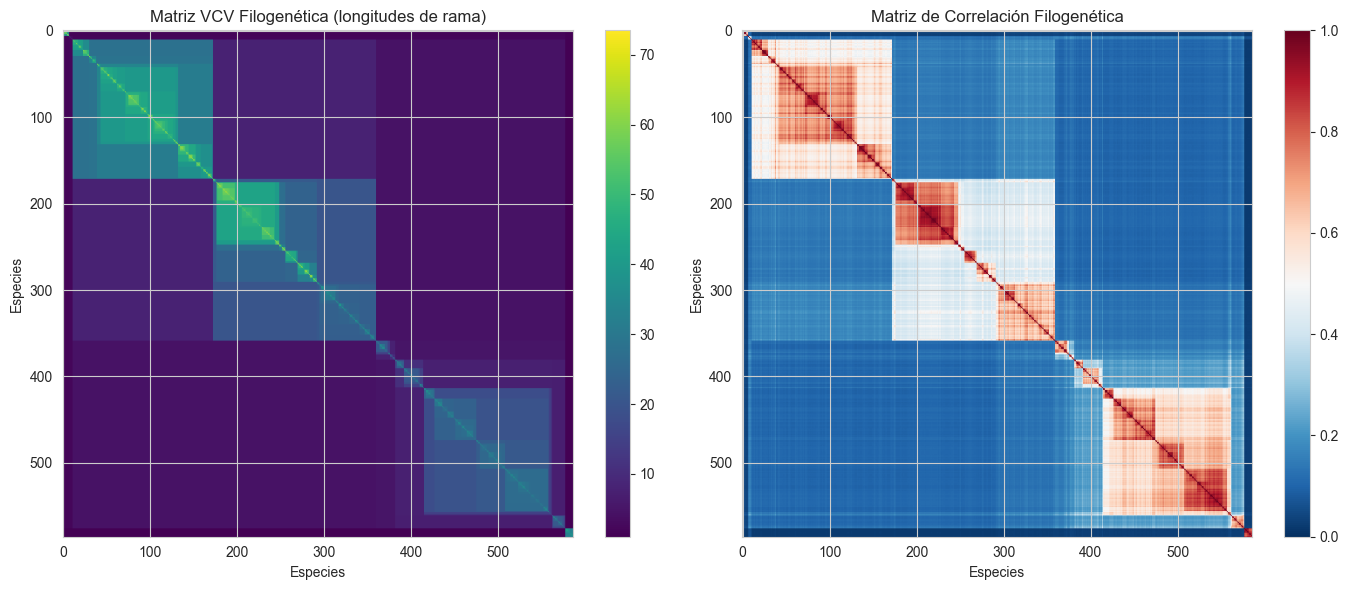

In [19]:
# Normalizar VCV para que la diagonal sea 1 (correlaciones)
vcv_diag = np.sqrt(np.diag(vcv_matrix))
vcv_corr = vcv_matrix / np.outer(vcv_diag, vcv_diag)

# Visualizar matriz VCV
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Matriz original
im1 = axes[0].imshow(vcv_matrix, cmap='viridis', aspect='auto')
axes[0].set_title('Matriz VCV Filogenética (longitudes de rama)')
axes[0].set_xlabel('Especies')
axes[0].set_ylabel('Especies')
plt.colorbar(im1, ax=axes[0])

# Matriz normalizada
im2 = axes[1].imshow(vcv_corr, cmap='RdBu_r', aspect='auto', vmin=0, vmax=1)
axes[1].set_title('Matriz de Correlación Filogenética')
axes[1].set_xlabel('Especies')
axes[1].set_ylabel('Especies')
plt.colorbar(im2, ax=axes[1])

plt.tight_layout()
plt.savefig('../fig/pgls_vcv_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Señal Filogenética

In [20]:
def pagel_lambda_likelihood(lam, y, vcv):
    """
    Calcula el log-likelihood negativo para un valor dado de lambda de Pagel.
    V_lambda = lambda * VCV + (1 - lambda) * I
    """
    n = len(y)
    I = np.eye(n)
    
    # Transformar matriz VCV con lambda
    V_lambda = lam * vcv + (1 - lam) * I
    
    try:
        # Calcular inversa y determinante
        V_inv = inv(V_lambda)
        sign, logdet = np.linalg.slogdet(V_lambda)
        
        if sign <= 0:
            return np.inf
        
        # ML estimate de la media
        ones = np.ones(n)
        mu = (ones @ V_inv @ y) / (ones @ V_inv @ ones)
        
        # Residuos
        resid = y - mu
        
        # ML estimate de sigma^2
        sigma2 = (resid @ V_inv @ resid) / n
        
        # Log-likelihood
        ll = -0.5 * (n * np.log(2 * np.pi) + n * np.log(sigma2) + logdet + n)
        
        return -ll  # Negativo para minimizar
    except:
        return np.inf

def estimate_pagel_lambda(y, vcv):
    """
    Estima lambda de Pagel por máxima verosimilitud.
    """
    # Normalizar VCV
    vcv_norm = vcv / vcv.max()
    
    # Optimizar lambda
    result = minimize_scalar(
        lambda lam: pagel_lambda_likelihood(lam, y, vcv_norm),
        bounds=(0, 1),
        method='bounded'
    )
    
    lambda_est = result.x
    ll_lambda = -result.fun
    
    # Log-likelihood bajo lambda=0 (sin señal filogenética)
    ll_0 = -pagel_lambda_likelihood(0, y, vcv_norm)
    
    # Log-likelihood bajo lambda=1 (movimiento Browniano)
    ll_1 = -pagel_lambda_likelihood(1, y, vcv_norm)
    
    # Likelihood ratio test vs lambda=0
    lr_stat = 2 * (ll_lambda - ll_0)
    p_value = 1 - stats.chi2.cdf(lr_stat, df=1) if lr_stat > 0 else 1.0
    
    return {
        'lambda': lambda_est,
        'loglik': ll_lambda,
        'loglik_0': ll_0,
        'loglik_1': ll_1,
        'LR_stat': lr_stat,
        'p_value': p_value
    }

In [21]:
def blomberg_k(y, vcv):
    """
    Calcula K de Blomberg.
    K = (MSE_obs / MSE_BM)
    donde MSE_obs es la varianza observada de los contrastes
    y MSE_BM es la esperada bajo movimiento Browniano.
    """
    n = len(y)
    
    # Normalizar VCV
    vcv_norm = vcv / vcv.max()
    
    try:
        V_inv = inv(vcv_norm)
    except:
        return {'K': np.nan, 'p_value': np.nan}
    
    ones = np.ones(n)
    
    # Media filogenética
    a = (ones @ V_inv @ y) / (ones @ V_inv @ ones)
    
    # MSE observado (varianza de los datos)
    mse_obs = np.var(y, ddof=0)
    
    # MSE esperado bajo BM
    resid = y - a
    mse_bm = (resid @ V_inv @ resid) / n
    
    # K de Blomberg
    # K = (MSE_obs/MSE_0) / (MSE_obs/MSE_BM_exp)
    # Simplificado: comparamos la varianza observada con la esperada bajo BM
    
    # Cálculo simplificado de K
    C = vcv_norm
    C_bar = C.mean()
    
    # Numerador: suma de cuadrados observada
    y_bar = y.mean()
    ss_obs = np.sum((y - y_bar)**2)
    
    # Denominador: suma de cuadrados esperada bajo BM
    # MSE esperado = traza(C) - n*C_bar
    mse_exp = (np.trace(C) - n * C_bar) / (n - 1)
    
    K = (mse_obs / n) / mse_exp if mse_exp > 0 else np.nan
    
    return {
        'K': K,
        'MSE_obs': mse_obs,
        'MSE_exp': mse_exp
    }

In [22]:
# Extraer F1-scores en el orden correcto
f1_scores = merged_df['f1-score'].values

# Verificar que tenemos suficientes datos
print(f"Número de especies con F1-scores: {len(f1_scores)}")

if len(f1_scores) < 10:
    print("⚠️  Muy pocas especies para el análisis. Verificar reconciliación de nombres.")
else:
    print("Calculando señal filogenética...")
    print("="*50)
    
    # Lambda de Pagel
    lambda_result = estimate_pagel_lambda(f1_scores, vcv_matrix)
    print(f"\nLAMBDA DE PAGEL")
    print(f"  λ estimado: {lambda_result['lambda']:.4f}")
    print(f"  Log-likelihood (λ óptimo): {lambda_result['loglik']:.2f}")
    print(f"  Log-likelihood (λ=0): {lambda_result['loglik_0']:.2f}")
    print(f"  Log-likelihood (λ=1): {lambda_result['loglik_1']:.2f}")
    print(f"  LR test vs λ=0: χ²={lambda_result['LR_stat']:.2f}, p={lambda_result['p_value']:.4f}")
    
    if lambda_result['lambda'] > 0.5:
        print(f"  → Señal filogenética FUERTE (λ > 0.5)")
    elif lambda_result['lambda'] > 0.1:
        print(f"  → Señal filogenética MODERADA (0.1 < λ < 0.5)")
    else:
        print(f"  → Señal filogenética DÉBIL (λ < 0.1)")

Número de especies con F1-scores: 586
Calculando señal filogenética...

LAMBDA DE PAGEL
  λ estimado: 0.1748
  Log-likelihood (λ óptimo): 778.36
  Log-likelihood (λ=0): 770.89
  Log-likelihood (λ=1): 583.72
  LR test vs λ=0: χ²=14.95, p=0.0001
  → Señal filogenética MODERADA (0.1 < λ < 0.5)


In [23]:
# K de Blomberg
k_result = blomberg_k(f1_scores, vcv_matrix)
print(f"\nK DE BLOMBERG")
print(f"  K estimado: {k_result['K']:.4f}")

if not np.isnan(k_result['K']):
    if k_result['K'] > 1:
        print(f"  → Más similares que lo esperado bajo BM (K > 1)")
    elif k_result['K'] < 1:
        print(f"  → Menos similares que lo esperado bajo BM (K < 1)")
    else:
        print(f"  → Consistente con movimiento Browniano (K ≈ 1)")


K DE BLOMBERG
  K estimado: 0.0000
  → Menos similares que lo esperado bajo BM (K < 1)


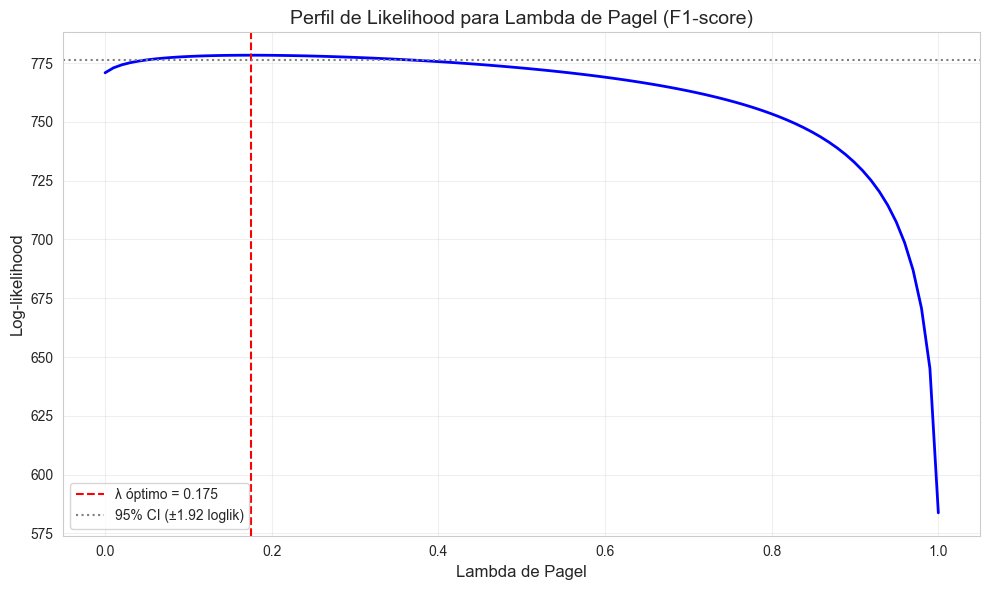

In [24]:
# Visualizar perfil de likelihood para lambda
if len(f1_scores) >= 10 and 'lambda_result' in dir():
    lambda_values = np.linspace(0, 1, 100)
    vcv_norm = vcv_matrix / vcv_matrix.max() if vcv_matrix.max() > 0 else vcv_matrix
    ll_values = [-pagel_lambda_likelihood(lam, f1_scores, vcv_norm) for lam in lambda_values]
    
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.plot(lambda_values, ll_values, 'b-', linewidth=2)
    ax.axvline(lambda_result['lambda'], color='r', linestyle='--', 
               label=f'λ óptimo = {lambda_result["lambda"]:.3f}')
    ax.axhline(lambda_result['loglik'] - 1.92, color='gray', linestyle=':', 
               label='95% CI (±1.92 loglik)')
    
    ax.set_xlabel('Lambda de Pagel', fontsize=12)
    ax.set_ylabel('Log-likelihood', fontsize=12)
    ax.set_title('Perfil de Likelihood para Lambda de Pagel (F1-score)', fontsize=14)
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('../fig/pgls_lambda_profile.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print("Saltando visualización de lambda - datos insuficientes o lambda no calculado")

## 5. Análisis PGLS

In [25]:
def fit_pgls(y, X, vcv, lambda_val=None):
    """
    Ajusta un modelo PGLS (Phylogenetic Generalized Least Squares).
    
    Si lambda_val es None, se estima por ML.
    Si lambda_val es un número, se usa ese valor fijo.
    """
    n = len(y)
    vcv_norm = vcv / vcv.max()
    
    # Estimar lambda si no se proporciona
    if lambda_val is None:
        def neg_ll(lam):
            V = lam * vcv_norm + (1 - lam) * np.eye(n)
            try:
                model = GLS(y, X, sigma=V)
                result = model.fit()
                return -result.llf
            except:
                return np.inf
        
        opt = minimize_scalar(neg_ll, bounds=(0, 1), method='bounded')
        lambda_val = opt.x
    
    # Ajustar modelo con lambda óptimo
    V_lambda = lambda_val * vcv_norm + (1 - lambda_val) * np.eye(n)
    
    model = GLS(y, X, sigma=V_lambda)
    result = model.fit()
    result.lambda_val = lambda_val
    
    return result

def fit_ols(y, X):
    """
    Ajusta un modelo OLS (sin corrección filogenética).
    """
    model = OLS(y, X)
    result = model.fit()
    return result

In [26]:
# Preparar datos para modelos
# Eliminar filas con valores faltantes en variables de interés
model_vars = morpho_available + geo_available
model_df = merged_df[['tree_name', 'f1-score'] + model_vars + eco_available].dropna()

print(f"Especies con datos completos: {len(model_df)}")

# Crear subset de VCV para especies con datos completos
model_species = model_df['tree_name'].tolist()
vcv_taxa_idx = {taxon: i for i, taxon in enumerate(vcv_taxa)}

# Filtrar model_df a especies que están en vcv_taxa
model_df = model_df[model_df['tree_name'].isin(vcv_taxa)]
model_species = model_df['tree_name'].tolist()

# Obtener índices en el orden correcto
model_idx = [vcv_taxa_idx[sp] for sp in model_species if sp in vcv_taxa_idx]

# Verificar que tenemos datos
if len(model_idx) == 0:
    print("⚠️  No hay especies en común entre el modelo y la matriz VCV")
    print(f"    Especies en model_df: {model_species[:5]}...")
    print(f"    Especies en vcv_taxa: {vcv_taxa[:5]}...")
else:
    vcv_subset = vcv_matrix[np.ix_(model_idx, model_idx)]
    print(f"VCV subset: {vcv_subset.shape}")

Especies con datos completos: 583
VCV subset: (583, 583)


In [27]:
# Variable respuesta
y = model_df['f1-score'].values

# Almacenar resultados de modelos
model_results = {}

In [28]:
# Modelo 1: OLS nulo (solo intercepto, sin corrección filogenética)
X_null = sm.add_constant(np.ones(len(y)))
ols_null = fit_ols(y, X_null[:, :1])
model_results['OLS_null'] = ols_null

print("MODELO 1: OLS Nulo (solo intercepto)")
print(f"  AIC: {ols_null.aic:.2f}")
print(f"  BIC: {ols_null.bic:.2f}")
print(f"  Log-likelihood: {ols_null.llf:.2f}")

MODELO 1: OLS Nulo (solo intercepto)
  AIC: -1532.94
  BIC: -1528.57
  Log-likelihood: 767.47


In [29]:
# Modelo 2: PGLS nulo (solo intercepto, con estructura filogenética)
pgls_null = fit_pgls(y, X_null[:, :1], vcv_subset)
model_results['PGLS_null'] = pgls_null

print("\nMODELO 2: PGLS Nulo (solo intercepto)")
print(f"  Lambda: {pgls_null.lambda_val:.4f}")
print(f"  AIC: {pgls_null.aic:.2f}")
print(f"  BIC: {pgls_null.bic:.2f}")
print(f"  Log-likelihood: {pgls_null.llf:.2f}")


MODELO 2: PGLS Nulo (solo intercepto)
  Lambda: 0.1721
  AIC: -1546.90
  BIC: -1542.54
  Log-likelihood: 774.45


In [30]:
# Modelo 3: PGLS Morfológico
# Log-transformar Mass y Range.Size para normalizar
model_df_log = model_df.copy()
if 'Mass' in model_df_log.columns:
    model_df_log['log_Mass'] = np.log10(model_df_log['Mass'] + 1)
if 'Range.Size' in model_df_log.columns:
    model_df_log['log_Range.Size'] = np.log10(model_df_log['Range.Size'] + 1)

# Variables morfológicas para el modelo
morpho_model_vars = []
for v in morpho_available:
    if v == 'Mass':
        morpho_model_vars.append('log_Mass')
    else:
        morpho_model_vars.append(v)

# Verificar que todas existen
morpho_model_vars = [v for v in morpho_model_vars if v in model_df_log.columns]

if len(morpho_model_vars) > 0:
    X_morpho = sm.add_constant(model_df_log[morpho_model_vars].values)
    pgls_morpho = fit_pgls(y, X_morpho, vcv_subset)
    model_results['PGLS_morpho'] = pgls_morpho
    
    print("\nMODELO 3: PGLS Morfológico")
    print(f"  Variables: {morpho_model_vars}")
    print(f"  Lambda: {pgls_morpho.lambda_val:.4f}")
    print(f"  AIC: {pgls_morpho.aic:.2f}")
    print(f"  R² ajustado: {pgls_morpho.rsquared_adj:.4f}")
    print(f"\n  Coeficientes:")
    for i, var in enumerate(['const'] + morpho_model_vars):
        coef = pgls_morpho.params[i]
        pval = pgls_morpho.pvalues[i]
        sig = '***' if pval < 0.001 else '**' if pval < 0.01 else '*' if pval < 0.05 else ''
        print(f"    {var}: {coef:.4f} (p={pval:.4f}) {sig}")


MODELO 3: PGLS Morfológico
  Variables: ['log_Mass', 'Beak.Length_Culmen', 'Beak.Length_Nares', 'Beak.Width', 'Beak.Depth', 'Tarsus.Length', 'Wing.Length', 'Tail.Length', 'Hand-Wing.Index']
  Lambda: 0.1343
  AIC: -1535.09
  R² ajustado: -0.0046

  Coeficientes:
    const: 0.8618 (p=0.0000) ***
    log_Mass: -0.0104 (p=0.6585) 
    Beak.Length_Culmen: -0.0002 (p=0.8953) 
    Beak.Length_Nares: -0.0004 (p=0.8319) 
    Beak.Width: 0.0021 (p=0.4880) 
    Beak.Depth: 0.0012 (p=0.6236) 
    Tarsus.Length: 0.0010 (p=0.1761) 
    Wing.Length: -0.0001 (p=0.7931) 
    Tail.Length: -0.0002 (p=0.2613) 
    Hand-Wing.Index: 0.0000 (p=0.9765) 


In [31]:
# Modelo 4: PGLS Ecológico (variables categóricas codificadas)
# Crear dummies para variables categóricas
eco_dummies = pd.get_dummies(model_df_log[eco_available], drop_first=True, dtype=float)

if eco_dummies.shape[1] > 0:
    X_eco = sm.add_constant(eco_dummies.values)
    pgls_eco = fit_pgls(y, X_eco, vcv_subset)
    model_results['PGLS_eco'] = pgls_eco
    
    print("\nMODELO 4: PGLS Ecológico")
    print(f"  Variables: {list(eco_dummies.columns)}")
    print(f"  Lambda: {pgls_eco.lambda_val:.4f}")
    print(f"  AIC: {pgls_eco.aic:.2f}")
    print(f"  R² ajustado: {pgls_eco.rsquared_adj:.4f}")


MODELO 4: PGLS Ecológico
  Variables: ['Habitat_Grassland', 'Habitat_Human Modified', 'Habitat_Riverine', 'Habitat_Rock', 'Habitat_Shrubland', 'Habitat_Wetland', 'Habitat_Woodland', 'Trophic.Level_Herbivore', 'Trophic.Level_Omnivore', 'Trophic.Niche_Granivore', 'Trophic.Niche_Invertivore', 'Trophic.Niche_Nectarivore', 'Trophic.Niche_Omnivore', 'Trophic.Niche_Vertivore', 'Primary.Lifestyle_Generalist', 'Primary.Lifestyle_Insessorial', 'Primary.Lifestyle_Terrestrial']
  Lambda: 0.1317
  AIC: -1533.28
  R² ajustado: 0.0057


In [32]:
# Modelo 5: PGLS Geográfico
geo_model_vars = []
for v in geo_available:
    if v == 'Range.Size':
        geo_model_vars.append('log_Range.Size')
    else:
        geo_model_vars.append(v)

geo_model_vars = [v for v in geo_model_vars if v in model_df_log.columns]

if len(geo_model_vars) > 0:
    X_geo = sm.add_constant(model_df_log[geo_model_vars].values)
    pgls_geo = fit_pgls(y, X_geo, vcv_subset)
    model_results['PGLS_geo'] = pgls_geo
    
    print("\nMODELO 5: PGLS Geográfico")
    print(f"  Variables: {geo_model_vars}")
    print(f"  Lambda: {pgls_geo.lambda_val:.4f}")
    print(f"  AIC: {pgls_geo.aic:.2f}")
    print(f"  R² ajustado: {pgls_geo.rsquared_adj:.4f}")
    print(f"\n  Coeficientes:")
    for i, var in enumerate(['const'] + geo_model_vars):
        coef = pgls_geo.params[i]
        pval = pgls_geo.pvalues[i]
        sig = '***' if pval < 0.001 else '**' if pval < 0.01 else '*' if pval < 0.05 else ''
        print(f"    {var}: {coef:.4f} (p={pval:.4f}) {sig}")


MODELO 5: PGLS Geográfico
  Variables: ['log_Range.Size', 'Centroid.Latitude', 'Centroid.Longitude']
  Lambda: 0.1368
  AIC: -1553.82
  R² ajustado: 0.0172

  Coeficientes:
    const: 0.9491 (p=0.0000) ***
    log_Range.Size: -0.0105 (p=0.0018) **
    Centroid.Latitude: 0.0004 (p=0.0359) *
    Centroid.Longitude: 0.0003 (p=0.0794) 


In [33]:
# Modelo 6: PGLS Completo (morfológico + ecológico + geográfico)
all_vars = morpho_model_vars + geo_model_vars
X_full_num = model_df_log[all_vars].values
X_full = np.hstack([X_full_num, eco_dummies.values])
X_full = sm.add_constant(X_full)

pgls_full = fit_pgls(y, X_full, vcv_subset)
model_results['PGLS_full'] = pgls_full

all_var_names = ['const'] + all_vars + list(eco_dummies.columns)

print("\nMODELO 6: PGLS Completo")
print(f"  Lambda: {pgls_full.lambda_val:.4f}")
print(f"  AIC: {pgls_full.aic:.2f}")
print(f"  R² ajustado: {pgls_full.rsquared_adj:.4f}")
print(f"\n  Coeficientes significativos (p < 0.05):")
for i, var in enumerate(all_var_names):
    if i < len(pgls_full.params):
        coef = pgls_full.params[i]
        pval = pgls_full.pvalues[i]
        if pval < 0.05:
            sig = '***' if pval < 0.001 else '**' if pval < 0.01 else '*'
            print(f"    {var}: {coef:.4f} (p={pval:.4f}) {sig}")


MODELO 6: PGLS Completo
  Lambda: 0.0725
  AIC: -1530.42
  R² ajustado: 0.0235

  Coeficientes significativos (p < 0.05):
    const: 0.9813 (p=0.0000) ***
    log_Range.Size: -0.0088 (p=0.0139) *
    Centroid.Latitude: 0.0005 (p=0.0181) *
    Trophic.Level_Herbivore: 0.0509 (p=0.0019) **
    Trophic.Niche_Invertivore: 0.0380 (p=0.0138) *
    Primary.Lifestyle_Insessorial: -0.0620 (p=0.0274) *


In [34]:
# Comparación de modelos por AIC
print("\n" + "="*60)
print("COMPARACIÓN DE MODELOS")
print("="*60)

comparison_data = []
for name, result in model_results.items():
    lam = getattr(result, 'lambda_val', 'N/A') if hasattr(result, 'lambda_val') else 'N/A'
    r2 = result.rsquared_adj if hasattr(result, 'rsquared_adj') else 'N/A'
    comparison_data.append({
        'Modelo': name,
        'AIC': result.aic,
        'BIC': result.bic,
        'Log-lik': result.llf,
        'Lambda': lam if isinstance(lam, str) else f"{lam:.3f}",
        'R² adj': r2 if isinstance(r2, str) else f"{r2:.4f}"
    })

comparison_df = pd.DataFrame(comparison_data)
comparison_df = comparison_df.sort_values('AIC')
comparison_df['ΔAIC'] = comparison_df['AIC'] - comparison_df['AIC'].min()

print(comparison_df.to_string(index=False))

best_model = comparison_df.iloc[0]['Modelo']
print(f"\n→ Mejor modelo: {best_model}")


COMPARACIÓN DE MODELOS
     Modelo          AIC          BIC    Log-lik Lambda  R² adj      ΔAIC
   PGLS_geo -1553.819372 -1536.346624 780.909686  0.137  0.0172  0.000000
  PGLS_null -1546.904384 -1542.536197 774.452192  0.172  0.0000  6.914989
PGLS_morpho -1535.087511 -1491.405639 777.543755  0.134 -0.0046 18.731861
   PGLS_eco -1533.278190 -1454.650821 784.639095  0.132  0.0057 20.541182
   OLS_null -1532.942003 -1528.573816 767.471002    N/A  0.0000 20.877369
  PGLS_full -1530.421319 -1399.375703 795.210659  0.072  0.0235 23.398054

→ Mejor modelo: PGLS_geo


## 6. Importancia de Variables

In [35]:
# Calcular coeficientes estandarizados para el modelo completo
# Para variables numéricas: beta_std = beta * (sd_x / sd_y)

sd_y = np.std(y)
numeric_vars = all_vars  # excluyendo dummies

standardized_coefs = []
for i, var in enumerate(all_var_names):
    if i == 0:  # intercepto
        continue
    if i >= len(pgls_full.params):
        continue
        
    coef = pgls_full.params[i]
    pval = pgls_full.pvalues[i]
    
    # Para variables numéricas, estandarizar
    if var in numeric_vars:
        var_idx = numeric_vars.index(var)
        sd_x = np.std(X_full_num[:, var_idx])
        std_coef = coef * (sd_x / sd_y)
    else:
        # Para dummies, usar coeficiente sin estandarizar o estandarizar por sd_y
        std_coef = coef / sd_y
    
    standardized_coefs.append({
        'Variable': var,
        'Coef': coef,
        'Std_Coef': std_coef,
        'Abs_Std_Coef': abs(std_coef),
        'p_value': pval,
        'Significativo': pval < 0.05
    })

importance_df = pd.DataFrame(standardized_coefs)
importance_df = importance_df.sort_values('Abs_Std_Coef', ascending=False)

print("IMPORTANCIA DE VARIABLES (Coeficientes Estandarizados)")
print("="*60)
print(importance_df[['Variable', 'Std_Coef', 'p_value', 'Significativo']].to_string(index=False))

IMPORTANCIA DE VARIABLES (Coeficientes Estandarizados)
                     Variable  Std_Coef  p_value  Significativo
      Trophic.Niche_Vertivore  1.362639 0.057060          False
Primary.Lifestyle_Insessorial -0.955582 0.027373           True
 Primary.Lifestyle_Generalist -0.866113 0.064148          False
      Trophic.Level_Herbivore  0.784371 0.001862           True
                 Habitat_Rock  0.690462 0.325472          False
Primary.Lifestyle_Terrestrial -0.668117 0.136917          False
              Habitat_Wetland -0.656912 0.145577          False
    Trophic.Niche_Invertivore  0.586533 0.013775           True
             Habitat_Riverine -0.325137 0.596947          False
       Trophic.Level_Omnivore  0.306211 0.061743          False
       Trophic.Niche_Omnivore  0.193281 0.359790          False
    Trophic.Niche_Nectarivore  0.189211 0.692763          False
                     log_Mass -0.178004 0.197607          False
                   Beak.Width  0.172136 0.222467 

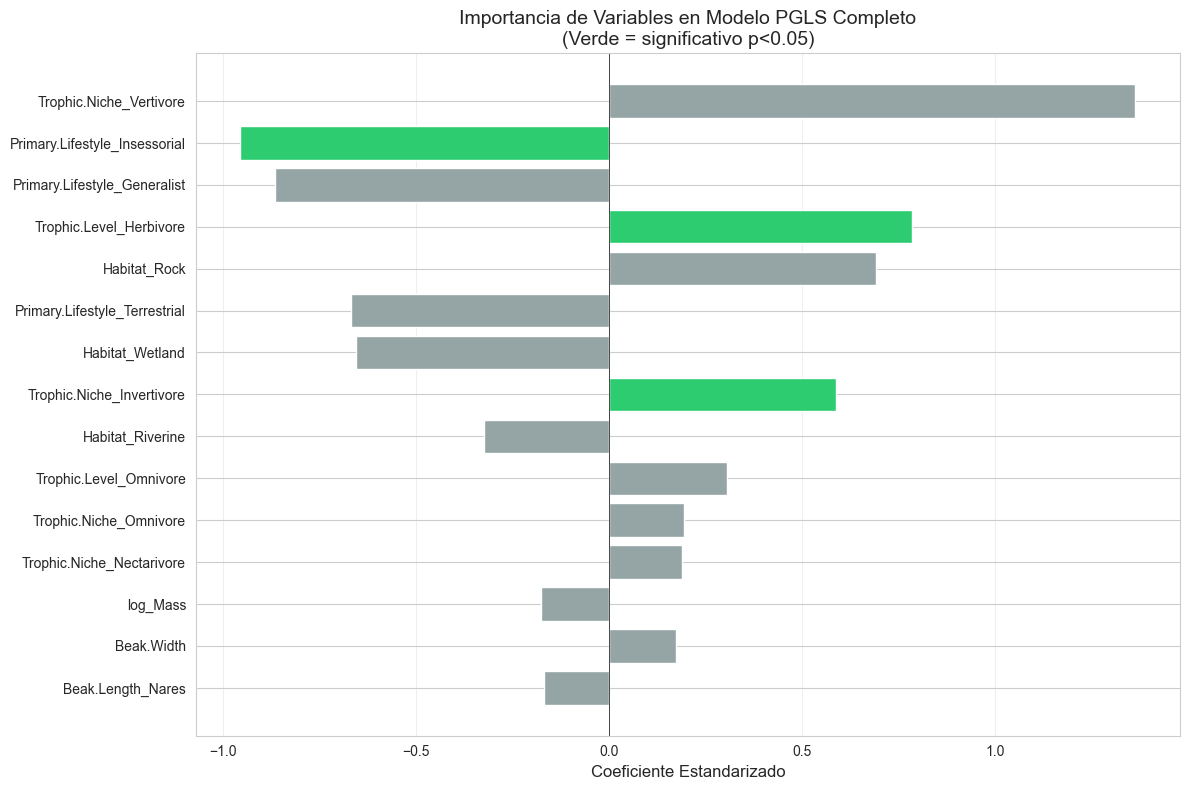

In [36]:
# Visualización de importancia de variables
fig, ax = plt.subplots(figsize=(12, 8))

# Solo mostrar top 15 variables
top_vars = importance_df.head(15)

colors = ['#2ecc71' if sig else '#95a5a6' for sig in top_vars['Significativo']]
bars = ax.barh(range(len(top_vars)), top_vars['Std_Coef'], color=colors)

ax.set_yticks(range(len(top_vars)))
ax.set_yticklabels(top_vars['Variable'])
ax.invert_yaxis()
ax.axvline(0, color='black', linewidth=0.5)
ax.set_xlabel('Coeficiente Estandarizado', fontsize=12)
ax.set_title('Importancia de Variables en Modelo PGLS Completo\n(Verde = significativo p<0.05)', fontsize=14)
ax.grid(True, axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('../fig/pgls_variable_importance.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Visualizaciones

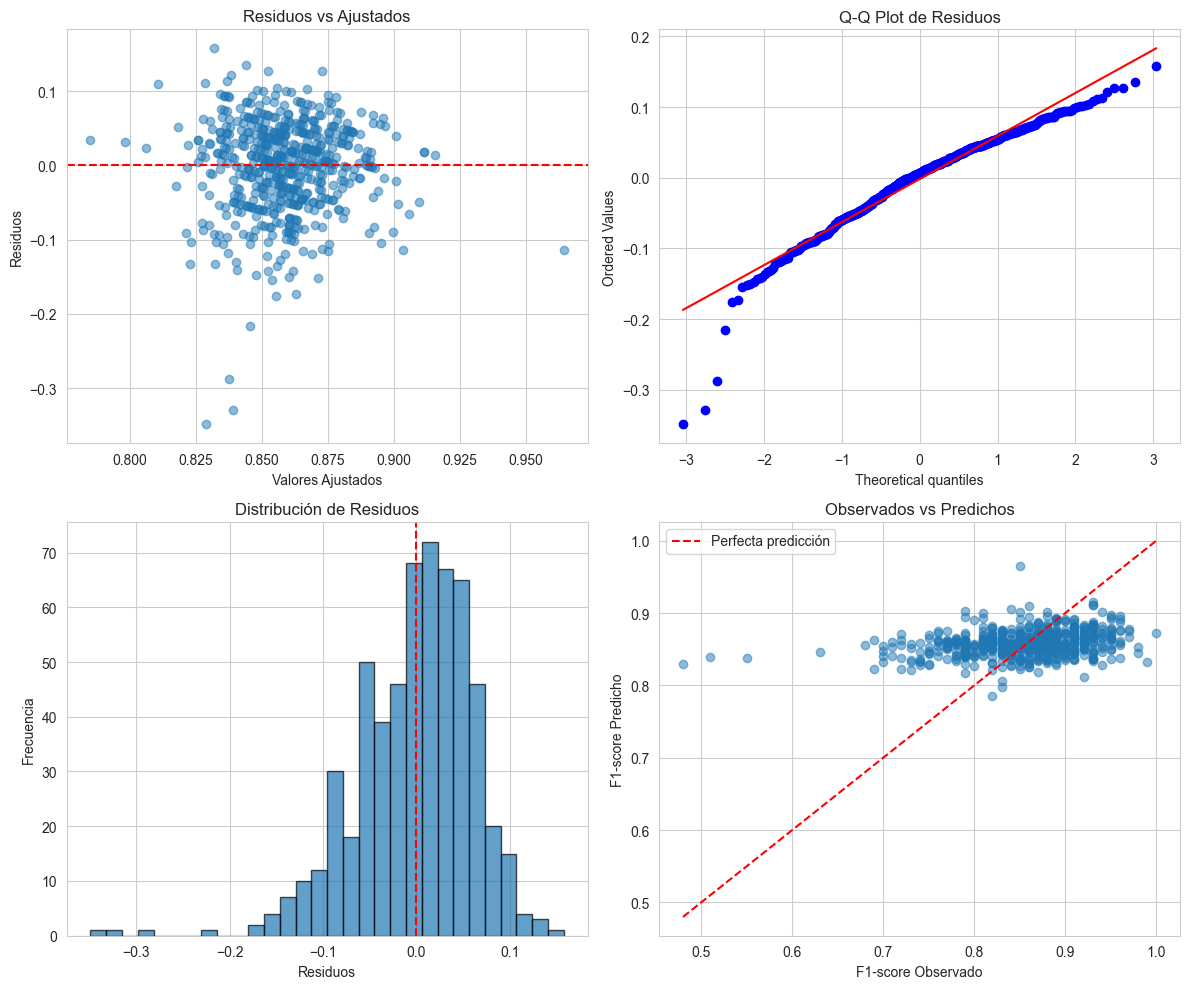

In [37]:
# Diagnósticos del mejor modelo PGLS
best_result = model_results.get('PGLS_full', pgls_full)

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# 1. Residuos vs Ajustados
ax1 = axes[0, 0]
ax1.scatter(best_result.fittedvalues, best_result.resid, alpha=0.5)
ax1.axhline(0, color='r', linestyle='--')
ax1.set_xlabel('Valores Ajustados')
ax1.set_ylabel('Residuos')
ax1.set_title('Residuos vs Ajustados')

# 2. Q-Q Plot
ax2 = axes[0, 1]
stats.probplot(best_result.resid, dist="norm", plot=ax2)
ax2.set_title('Q-Q Plot de Residuos')

# 3. Histograma de residuos
ax3 = axes[1, 0]
ax3.hist(best_result.resid, bins=30, edgecolor='black', alpha=0.7)
ax3.axvline(0, color='r', linestyle='--')
ax3.set_xlabel('Residuos')
ax3.set_ylabel('Frecuencia')
ax3.set_title('Distribución de Residuos')

# 4. Observados vs Predichos
ax4 = axes[1, 1]
ax4.scatter(y, best_result.fittedvalues, alpha=0.5)
ax4.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', label='Perfecta predicción')
ax4.set_xlabel('F1-score Observado')
ax4.set_ylabel('F1-score Predicho')
ax4.set_title('Observados vs Predichos')
ax4.legend()

plt.tight_layout()
plt.savefig('../fig/pgls_diagnostics.png', dpi=150, bbox_inches='tight')
plt.show()

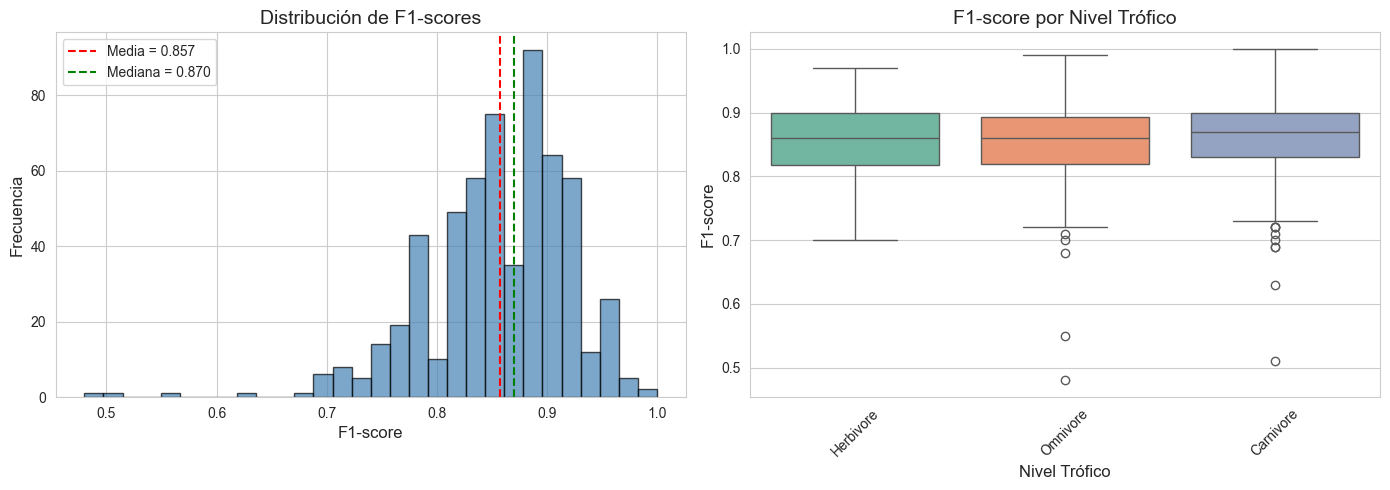

In [38]:
# Distribución de F1-scores
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histograma de F1-scores
ax1 = axes[0]
ax1.hist(f1_scores, bins=30, edgecolor='black', alpha=0.7, color='steelblue')
ax1.axvline(f1_scores.mean(), color='r', linestyle='--', label=f'Media = {f1_scores.mean():.3f}')
ax1.axvline(np.median(f1_scores), color='g', linestyle='--', label=f'Mediana = {np.median(f1_scores):.3f}')
ax1.set_xlabel('F1-score', fontsize=12)
ax1.set_ylabel('Frecuencia', fontsize=12)
ax1.set_title('Distribución de F1-scores', fontsize=14)
ax1.legend()

# Boxplot por categoría ecológica (si disponible)
ax2 = axes[1]
if 'Trophic.Level' in model_df.columns:
    trophic_data = model_df[['f1-score', 'Trophic.Level']].dropna()
    trophic_order = trophic_data.groupby('Trophic.Level')['f1-score'].median().sort_values().index
    sns.boxplot(data=trophic_data, x='Trophic.Level', y='f1-score', 
                order=trophic_order, ax=ax2, palette='Set2')
    ax2.set_xlabel('Nivel Trófico', fontsize=12)
    ax2.set_ylabel('F1-score', fontsize=12)
    ax2.set_title('F1-score por Nivel Trófico', fontsize=14)
    ax2.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('../fig/pgls_f1_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

In [39]:
# Identificar especies con rendimiento atípico (residuos extremos)
residuals = best_result.resid
residual_std = (residuals - residuals.mean()) / residuals.std()

model_df_results = model_df.copy()
model_df_results['residual'] = residuals
model_df_results['residual_std'] = residual_std
model_df_results['predicted'] = best_result.fittedvalues

# Especies que sobre-rinden (residuos positivos altos)
over_performers = model_df_results[model_df_results['residual_std'] > 2].sort_values('residual_std', ascending=False)

# Especies que sub-rinden (residuos negativos altos)
under_performers = model_df_results[model_df_results['residual_std'] < -2].sort_values('residual_std')

print("ESPECIES CON RENDIMIENTO ATÍPICO")
print("="*60)
print(f"\nSobre-rinden (residuo std > 2): {len(over_performers)} especies")
if len(over_performers) > 0:
    print(over_performers[['tree_name', 'f1-score', 'predicted', 'residual_std']].head(10).to_string(index=False))

print(f"\nSub-rinden (residuo std < -2): {len(under_performers)} especies")
if len(under_performers) > 0:
    print(under_performers[['tree_name', 'f1-score', 'predicted', 'residual_std']].head(10).to_string(index=False))

ESPECIES CON RENDIMIENTO ATÍPICO

Sobre-rinden (residuo std > 2): 4 especies
                tree_name  f1-score  predicted  residual_std
Sericossypha_albocristata      0.99   0.832114      2.568688
    Automolus_melanopezus      0.98   0.844132      2.214646
         Neoctantes_niger      0.98   0.852487      2.080310
    Myiornis_atricapillus      1.00   0.872793      2.075386

Sub-rinden (residuo std < -2): 18 especies
               tree_name  f1-score  predicted  residual_std
       Lipaugus_unirufus      0.48   0.828961     -5.581219
         Nemosia_pileata      0.51   0.839146     -5.262610
    Molothrus_oryzivorus      0.55   0.837600     -4.594556
 Dendrexetastes_rufigula      0.63   0.845671     -3.437968
   Atlapetes_leucopterus      0.68   0.855417     -2.790700
Pachyramphus_cinnamomeus      0.69   0.863097     -2.753389
     Tityra_semifasciata      0.70   0.853864     -2.444139
   Thamnophilus_unicolor      0.72   0.871548     -2.406888
   Sporophila_schistacea      0.71

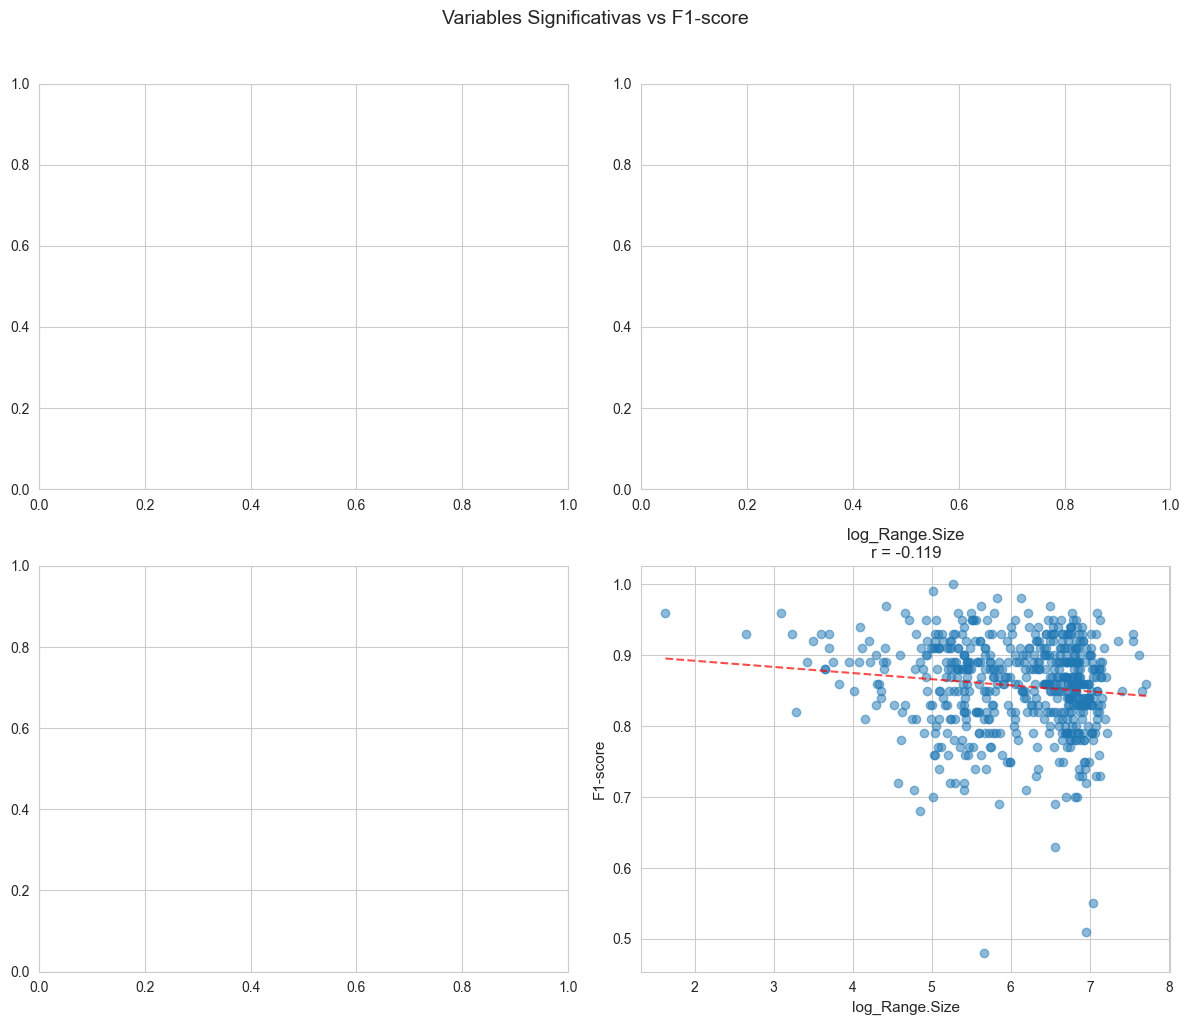

In [40]:
# Scatter plots de variables más importantes vs F1-score
sig_vars = importance_df[importance_df['Significativo']]['Variable'].tolist()[:4]

if len(sig_vars) > 0:
    n_plots = min(4, len(sig_vars))
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))
    axes = axes.flatten()
    
    for i, var in enumerate(sig_vars[:n_plots]):
        ax = axes[i]
        if var in model_df_log.columns:
            ax.scatter(model_df_log[var], y, alpha=0.5)
            ax.set_xlabel(var, fontsize=11)
            ax.set_ylabel('F1-score', fontsize=11)
            
            # Añadir línea de tendencia
            z = np.polyfit(model_df_log[var].dropna(), 
                          y[~model_df_log[var].isna()], 1)
            p = np.poly1d(z)
            x_line = np.linspace(model_df_log[var].min(), model_df_log[var].max(), 100)
            ax.plot(x_line, p(x_line), 'r--', alpha=0.7)
            
            # Correlación
            corr = model_df_log[var].corr(pd.Series(y, index=model_df_log.index))
            ax.set_title(f'{var}\nr = {corr:.3f}', fontsize=12)
    
    # Ocultar ejes vacíos
    for j in range(n_plots, 4):
        axes[j].set_visible(False)
    
    plt.suptitle('Variables Significativas vs F1-score', fontsize=14, y=1.02)
    plt.tight_layout()
    plt.savefig('../fig/pgls_significant_vars.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print("No se encontraron variables significativas para graficar.")

## 8. Resumen y Conclusiones

In [41]:
print("="*70)
print("RESUMEN DEL ANÁLISIS PGLS")
print("="*70)

print(f"\n1. DATOS")
print(f"   - Especies analizadas: {len(model_df)}")
print(f"   - F1-score promedio: {f1_scores.mean():.3f} ± {f1_scores.std():.3f}")
print(f"   - Rango F1-score: [{f1_scores.min():.3f}, {f1_scores.max():.3f}]")

print(f"\n2. SEÑAL FILOGENÉTICA")
print(f"   - Lambda de Pagel: {lambda_result['lambda']:.4f}")
if lambda_result['p_value'] < 0.05:
    print(f"   - Significativamente diferente de 0 (p = {lambda_result['p_value']:.4f})")
else:
    print(f"   - No significativamente diferente de 0 (p = {lambda_result['p_value']:.4f})")
    
if lambda_result['lambda'] > 0.5:
    interp = "FUERTE: La filogenia explica >50% de la varianza en F1-score"
elif lambda_result['lambda'] > 0.1:
    interp = "MODERADA: La filogenia explica parte de la varianza en F1-score"
else:
    interp = "DÉBIL: La filogenia explica poca varianza en F1-score"
print(f"   - Interpretación: {interp}")

print(f"\n3. COMPARACIÓN DE MODELOS")
print(comparison_df[['Modelo', 'AIC', 'ΔAIC', 'R² adj']].to_string(index=False))

print(f"\n4. VARIABLES SIGNIFICATIVAS (p < 0.05)")
sig_only = importance_df[importance_df['Significativo']]
if len(sig_only) > 0:
    for _, row in sig_only.iterrows():
        direction = "↑" if row['Std_Coef'] > 0 else "↓"
        print(f"   - {row['Variable']}: β_std = {row['Std_Coef']:.4f} {direction} (p = {row['p_value']:.4f})")
else:
    print("   Ninguna variable fue significativa")

print(f"\n5. ESPECIES ATÍPICAS")
print(f"   - Sobre-rinden: {len(over_performers)} especies")
print(f"   - Sub-rinden: {len(under_performers)} especies")

RESUMEN DEL ANÁLISIS PGLS

1. DATOS
   - Especies analizadas: 583
   - F1-score promedio: 0.857 ± 0.065
   - Rango F1-score: [0.480, 1.000]

2. SEÑAL FILOGENÉTICA
   - Lambda de Pagel: 0.1748
   - Significativamente diferente de 0 (p = 0.0001)
   - Interpretación: MODERADA: La filogenia explica parte de la varianza en F1-score

3. COMPARACIÓN DE MODELOS
     Modelo          AIC      ΔAIC  R² adj
   PGLS_geo -1553.819372  0.000000  0.0172
  PGLS_null -1546.904384  6.914989  0.0000
PGLS_morpho -1535.087511 18.731861 -0.0046
   PGLS_eco -1533.278190 20.541182  0.0057
   OLS_null -1532.942003 20.877369  0.0000
  PGLS_full -1530.421319 23.398054  0.0235

4. VARIABLES SIGNIFICATIVAS (p < 0.05)
   - Primary.Lifestyle_Insessorial: β_std = -0.9556 ↓ (p = 0.0274)
   - Trophic.Level_Herbivore: β_std = 0.7844 ↑ (p = 0.0019)
   - Trophic.Niche_Invertivore: β_std = 0.5865 ↑ (p = 0.0138)
   - log_Range.Size: β_std = -0.1212 ↓ (p = 0.0139)
   - Centroid.Latitude: β_std = 0.1195 ↑ (p = 0.0181)

5. ESPE

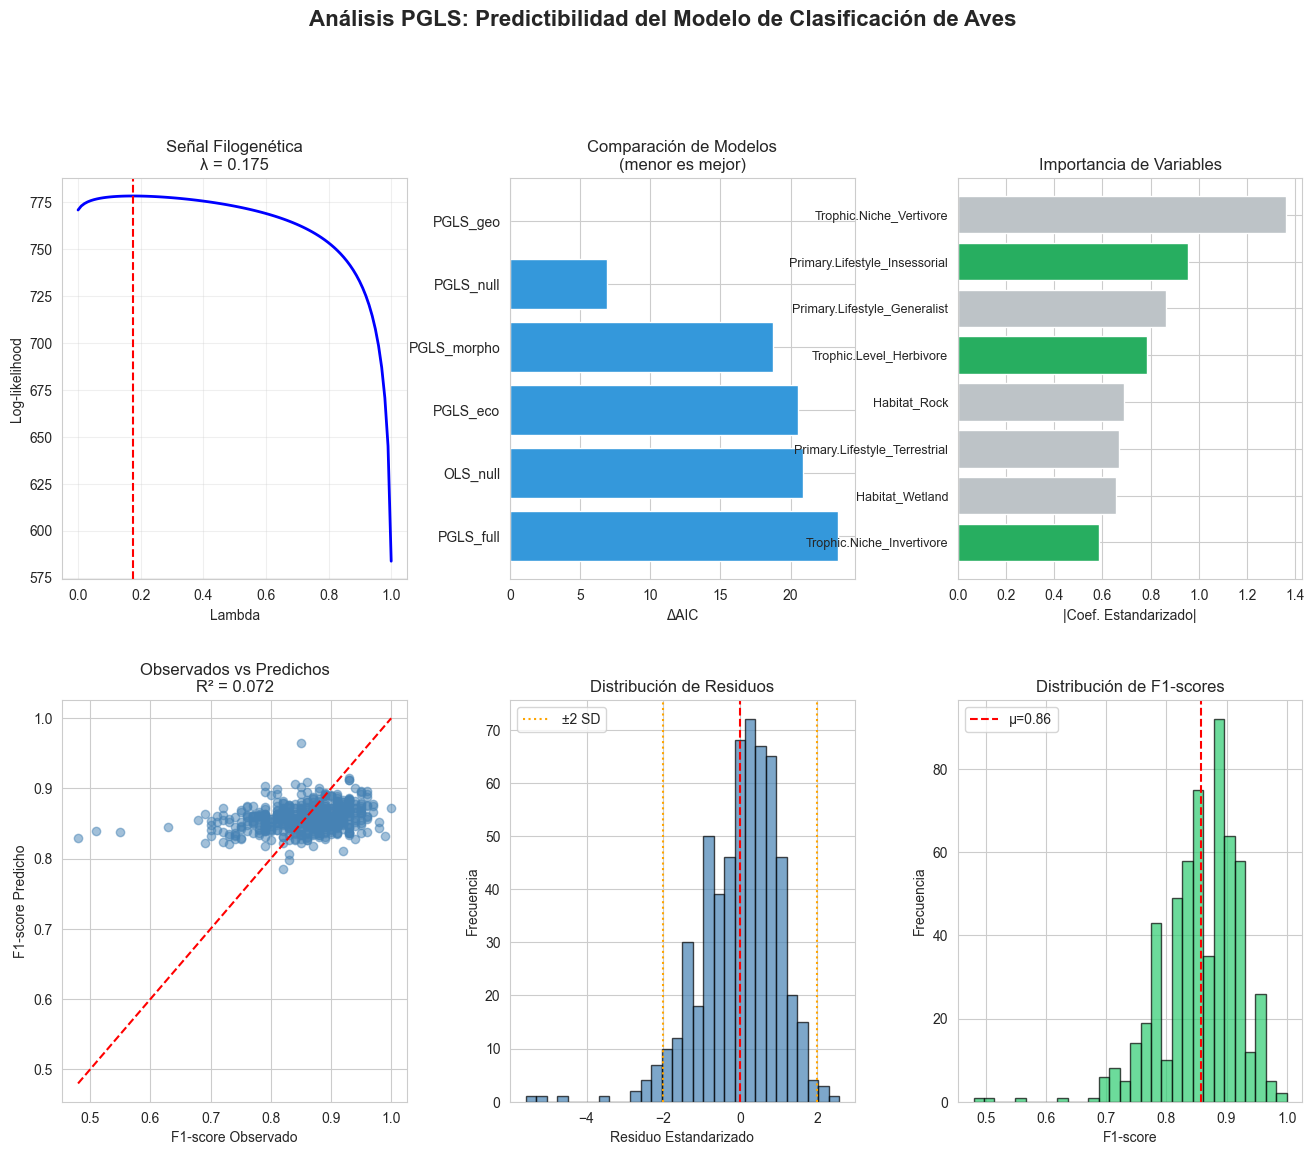

In [42]:
# Panel de resumen visual
fig = plt.figure(figsize=(16, 12))

# Layout: 2x3 grid
gs = fig.add_gridspec(2, 3, hspace=0.3, wspace=0.3)

# 1. Lambda profile
ax1 = fig.add_subplot(gs[0, 0])
ax1.plot(lambda_values, ll_values, 'b-', linewidth=2)
ax1.axvline(lambda_result['lambda'], color='r', linestyle='--')
ax1.set_xlabel('Lambda')
ax1.set_ylabel('Log-likelihood')
ax1.set_title(f'Señal Filogenética\nλ = {lambda_result["lambda"]:.3f}')
ax1.grid(True, alpha=0.3)

# 2. Comparación de modelos (AIC)
ax2 = fig.add_subplot(gs[0, 1])
models = comparison_df['Modelo'].values
aics = comparison_df['ΔAIC'].values
colors = ['#e74c3c' if aic == 0 else '#3498db' for aic in aics]
ax2.barh(models, aics, color=colors)
ax2.set_xlabel('ΔAIC')
ax2.set_title('Comparación de Modelos\n(menor es mejor)')
ax2.invert_yaxis()

# 3. Importancia de variables (top 8)
ax3 = fig.add_subplot(gs[0, 2])
top8 = importance_df.head(8)
colors = ['#27ae60' if sig else '#bdc3c7' for sig in top8['Significativo']]
ax3.barh(range(len(top8)), top8['Abs_Std_Coef'], color=colors)
ax3.set_yticks(range(len(top8)))
ax3.set_yticklabels(top8['Variable'], fontsize=9)
ax3.invert_yaxis()
ax3.set_xlabel('|Coef. Estandarizado|')
ax3.set_title('Importancia de Variables')

# 4. Observados vs Predichos
ax4 = fig.add_subplot(gs[1, 0])
ax4.scatter(y, best_result.fittedvalues, alpha=0.5, c='steelblue')
ax4.plot([y.min(), y.max()], [y.min(), y.max()], 'r--')
ax4.set_xlabel('F1-score Observado')
ax4.set_ylabel('F1-score Predicho')
ax4.set_title(f'Observados vs Predichos\nR² = {best_result.rsquared:.3f}')

# 5. Distribución de residuos
ax5 = fig.add_subplot(gs[1, 1])
ax5.hist(residual_std, bins=30, edgecolor='black', alpha=0.7, color='steelblue')
ax5.axvline(0, color='r', linestyle='--')
ax5.axvline(-2, color='orange', linestyle=':', label='±2 SD')
ax5.axvline(2, color='orange', linestyle=':')
ax5.set_xlabel('Residuo Estandarizado')
ax5.set_ylabel('Frecuencia')
ax5.set_title('Distribución de Residuos')
ax5.legend()

# 6. F1-score distribution
ax6 = fig.add_subplot(gs[1, 2])
ax6.hist(f1_scores, bins=30, edgecolor='black', alpha=0.7, color='#2ecc71')
ax6.axvline(f1_scores.mean(), color='r', linestyle='--', label=f'μ={f1_scores.mean():.2f}')
ax6.set_xlabel('F1-score')
ax6.set_ylabel('Frecuencia')
ax6.set_title('Distribución de F1-scores')
ax6.legend()

plt.suptitle('Análisis PGLS: Predictibilidad del Modelo de Clasificación de Aves', 
             fontsize=16, fontweight='bold', y=1.02)
plt.savefig('../fig/pgls_summary_panel.png', dpi=150, bbox_inches='tight')
plt.show()

In [43]:
# Guardar resultados
results_summary = {
    'n_species': len(model_df),
    'lambda_pagel': lambda_result['lambda'],
    'lambda_pvalue': lambda_result['p_value'],
    'blomberg_k': k_result['K'],
    'best_model': best_model,
    'best_model_aic': comparison_df.iloc[0]['AIC'],
    'best_model_r2': float(comparison_df.iloc[0]['R² adj'].replace('N/A', 'nan')),
    'n_significant_vars': len(sig_only),
    'n_over_performers': len(over_performers),
    'n_under_performers': len(under_performers)
}

# Guardar como CSV
model_df_results.to_csv('../src/data/pgls_species_results.csv', index=False)
importance_df.to_csv('../src/data/pgls_variable_importance.csv', index=False)
comparison_df.to_csv('../src/data/pgls_model_comparison.csv', index=False)

print("Resultados guardados en:")
print("  - ../src/data/pgls_species_results.csv")
print("  - ../src/data/pgls_variable_importance.csv")
print("  - ../src/data/pgls_model_comparison.csv")
print("\nFiguras guardadas en:")
print("  - ../fig/pgls_vcv_matrix.png")
print("  - ../fig/pgls_lambda_profile.png")
print("  - ../fig/pgls_variable_importance.png")
print("  - ../fig/pgls_diagnostics.png")
print("  - ../fig/pgls_f1_distribution.png")
print("  - ../fig/pgls_significant_vars.png")
print("  - ../fig/pgls_summary_panel.png")

Resultados guardados en:
  - ../src/data/pgls_species_results.csv
  - ../src/data/pgls_variable_importance.csv
  - ../src/data/pgls_model_comparison.csv

Figuras guardadas en:
  - ../fig/pgls_vcv_matrix.png
  - ../fig/pgls_lambda_profile.png
  - ../fig/pgls_variable_importance.png
  - ../fig/pgls_diagnostics.png
  - ../fig/pgls_f1_distribution.png
  - ../fig/pgls_significant_vars.png
  - ../fig/pgls_summary_panel.png


---

## Interpretación Biológica

### Señal Filogenética
- **Lambda alto (>0.5)**: Especies cercanamente relacionadas tienen F1-scores similares, sugiriendo que características heredadas (morfología, comportamiento, vocalización) influyen en la clasificabilidad.
- **Lambda bajo (<0.5)**: La predictibilidad del modelo está menos determinada por la filogenia, posiblemente influenciada más por factores ecológicos o ambientales.

### Variables Predictoras
- **Morfológicas**: Si variables como masa corporal o longitud de ala son significativas, sugiere que aves de ciertos tamaños/formas son más fáciles de clasificar acústicamente.
- **Ecológicas**: Variables como nivel trófico o hábitat pueden indicar que ciertos nichos ecológicos producen vocalizaciones más distintivas.
- **Geográficas**: El tamaño del rango o latitud pueden reflejar variabilidad intraespecífica en vocalizaciones.

### Especies Atípicas
- **Sobre-rinden**: Especies con F1-score mayor al esperado pueden tener vocalizaciones particularmente distintivas.
- **Sub-rinden**: Especies con F1-score menor al esperado pueden tener vocalizaciones similares a otras especies o alta variabilidad intraespecífica.